# 05 - Feature Relevance Audit

Uses the best tree-based model from notebook 04 to compute permutation importance, then saves only the features that contribute meaningfully to `debug_exports/top_features.json`.

to_csv failed: 'Index' object has no attribute '_format_native_types'
Saved CSV → /home/mwasifshakeel/Videos/pearls-aqi-predictor/debug_exports/feature_importance.csv


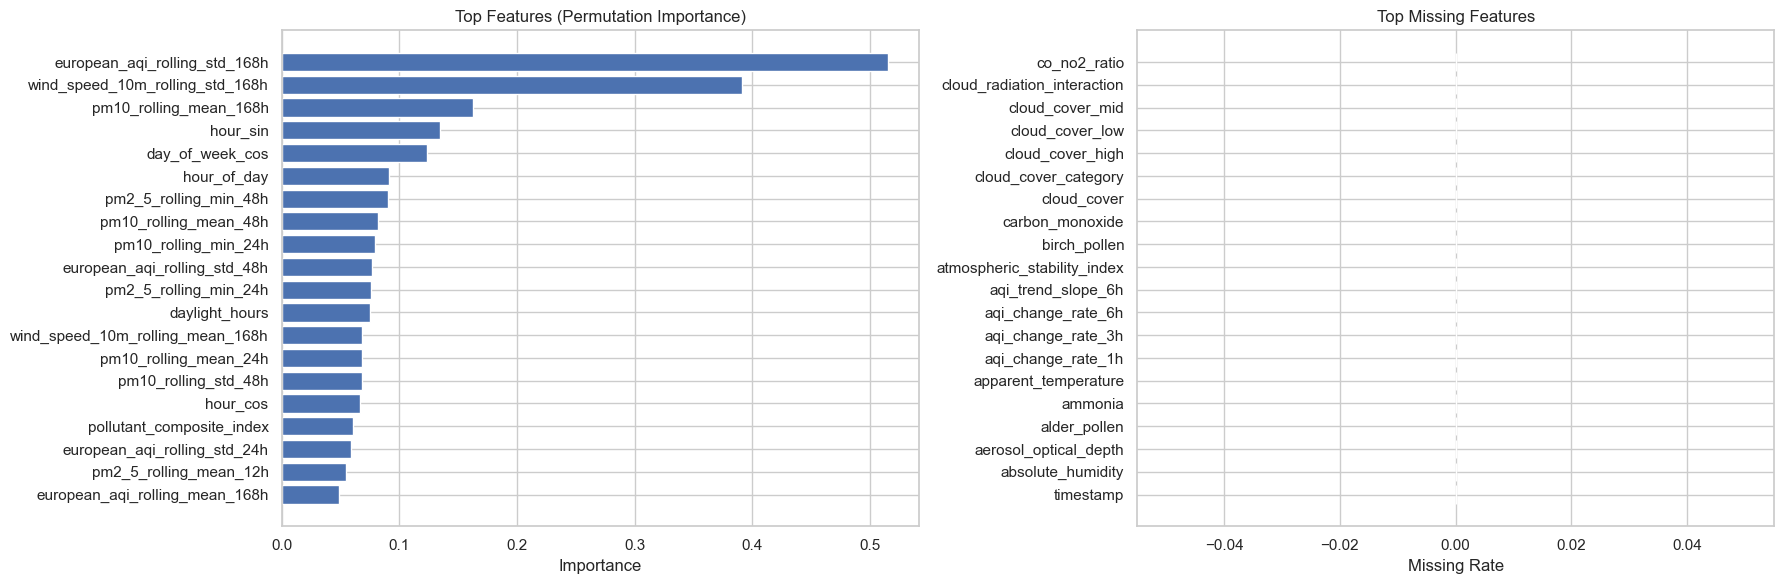

In [12]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from IPython.display import display

from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, mean_squared_error
import sys
import os
sys.path.append(os.path.abspath("../.."))
from src.data.fetch_openmeteo import AIR_QUALITY_HOURLY, WEATHER_HOURLY
from src.features.feature_catalog import get_feature_catalog
from src.models.model_configs import MODEL_CONFIGS
from src.models.train import train_model
from src.utils.mongo_client import get_database

# ─────────────────────────────────────────────────────────────
# Setup
# ─────────────────────────────────────────────────────────────

sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
load_dotenv(str(ROOT / ".env"), override=False)

ARTIFACTS_DIR = ROOT / "debug_exports"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

TREE_MODEL_NAMES = {
    "lightgbm", "xgboost", "catboost",
    "random_forest", "extra_trees", "gradient_boosting"
}

HORIZON = 72
SPLIT_RATIO = 0.9

# ─────────────────────────────────────────────────────────────
# Load Data
# ─────────────────────────────────────────────────────────────

db = get_database()
collection = db["aqi_features_rawalpindi"]

data = pd.DataFrame(list(collection.find()))

if data.empty:
    raise ValueError("AQI collection is empty")

data = data.drop(columns=["_id"], errors="ignore")

data["timestamp"] = pd.to_datetime(data["timestamp"], utc=True, errors="coerce")

data = (
    data.dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .reset_index(drop=True)
)
# ─────────────────────────────────────────────────────────────
# Feature selection base
# ─────────────────────────────────────────────────────────────

feature_cols = [c for c in get_feature_catalog() if c in data.columns]

best_window_days = 80
window_start = data["timestamp"].max() - pd.Timedelta(days=best_window_days)

window_df = (
    data[data["timestamp"] >= window_start]
    .reset_index(drop=True)
)

if len(window_df) <= HORIZON:
    raise ValueError("Not enough data for feature importance window")

split_index = int(len(window_df) * SPLIT_RATIO)

# ─────────────────────────────────────────────────────────────
# Prepare matrices (LEAKAGE SAFE)
# ─────────────────────────────────────────────────────────────

def make_supervised(frame, target, horizon):
    X = frame.iloc[:-horizon].copy()

    y = np.array([
        target.iloc[i:i+horizon].values
        for i in range(len(X))
    ])

    return X, y


target = window_df["european_aqi"].astype(float)

feature_frame = window_df[feature_cols].apply(pd.to_numeric, errors="coerce")
feature_frame = feature_frame.replace([np.inf, -np.inf], np.nan).ffill().fillna(0.0)

feature_frame = feature_frame.loc[:, feature_frame.nunique() > 1]

X, y = make_supervised(feature_frame, target, HORIZON)

y = pd.DataFrame(y)
train_size = int(len(X) * SPLIT_RATIO)

x_train, x_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

# ─────────────────────────────────────────────────────────────
# Model
# ─────────────────────────────────────────────────────────────

best_tree_model_name = "catboost"
model_config = next(c for c in MODEL_CONFIGS if c.name == best_tree_model_name)

model, _, _ = train_model(model_config, x_train, y_train, horizon=HORIZON)

# ─────────────────────────────────────────────────────────────
# RMSE scorer
# ─────────────────────────────────────────────────────────────

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scorer = make_scorer(rmse, greater_is_better=False)

# ─────────────────────────────────────────────────────────────
# Permutation importance
# ─────────────────────────────────────────────────────────────

importance = permutation_importance(
    model,
    x_val,
    y_val,
    n_repeats=5,
    random_state=42,
    scoring=scorer
)

importance_df = pd.DataFrame({
    "feature": x_val.columns,
    "importance": importance.importances_mean
})

importance_df["importance"] = importance_df["importance"].clip(lower=0)
importance_df = importance_df.sort_values("importance", ascending=False)

# Normalize
total = importance_df["importance"].sum()
importance_df["share"] = importance_df["importance"] / total if total > 0 else 0
importance_df["cumulative_share"] = importance_df["share"].cumsum()

# ─────────────────────────────────────────────────────────────
# Feature selection
# ─────────────────────────────────────────────────────────────

selected_features = importance_df.loc[
    importance_df["cumulative_share"] <= 0.95,
    "feature"
].tolist()

if len(selected_features) < 12:
    selected_features = importance_df.head(20)["feature"].tolist()

selected_features = selected_features[:40]

# ─────────────────────────────────────────────────────────────
# Save artifacts
# ─────────────────────────────────────────────────────────────

payload = {
    "features": selected_features,
    "model_name": best_tree_model_name,
    "window_days": best_window_days,
    "feature_count": len(selected_features),
    "rule": "permutation_importance_0.95"
}

with open(ARTIFACTS_DIR / "top_features.json", "w") as f:
    json.dump(payload, f, indent=2)

# Create a clean dataframe copy
importance_export = pd.DataFrame({
    "feature": importance_df["feature"].astype(str),
    "importance": importance_df["importance"].astype(float),
    "share": importance_df["share"].astype(float),
    "cumulative_share": importance_df["cumulative_share"].astype(float)
})

# Save CSV
csv_path = ARTIFACTS_DIR / "feature_importance.csv"

try:
    importance_export.to_csv(csv_path, index=False)
except Exception as e:
    print(f"to_csv failed: {e}")

    # Fallback writer
    with open(csv_path, "w", encoding="utf-8") as f:
        f.write(",".join(importance_export.columns) + "\n")

        for row in importance_export.itertuples(index=False):
            f.write(",".join(map(str, row)) + "\n")

print(f"Saved CSV → {csv_path}")

# ─────────────────────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top feature importance
top20 = importance_df.head(20).sort_values("importance")

axes[0].barh(
    top20["feature"],
    top20["importance"]
)

axes[0].set_title("Top Features (Permutation Importance)")
axes[0].set_xlabel("Importance")

# Missingness
missingness = (
    data.isna()
        .mean()
        .sort_values(ascending=False)
        .head(20)
)

axes[1].barh(
    missingness.index.astype(str),
    missingness.values
)

axes[1].set_title("Top Missing Features")
axes[1].set_xlabel("Missing Rate")

plt.tight_layout()
plt.show()